# 13 — Computational Efficiency Analysis — **CORRECTED VERSION**

**Section 4.1.4 item #8: Computational Efficiency Analysis**

### What changed from the previous version
The earlier version trained `build_lstm_transformer()` defined as `LSTM(16) + AttentionExtractor
(MultiHeadAttention) + GlobalAveragePooling1D`, no dual-path fusion, on the old 53-feature
dataset (`processed_data/all_data.pkl`). That model has 7,041 parameters — not the ~41,000
described in Thesis Section 3.5.2 — so every number in the old efficiency table (train time,
inference latency, model size, RAM) described a model that is not the one in Chapter 3.

This version measures the **4 models actually defined in Table 3.2** (SARIMA, Random Forest,
Standalone LSTM, ILT — proposed), all imported from `canonical_pipeline.py`, all evaluated on
the same 60-feature (DL) / 45-feature (RF) canonical dataset used in Notebook 08. "Vanilla
Transformer" is dropped from the comparison table since it is not one of the three baselines
named in Section 3.3.1 — keeping it would re-introduce the same baseline-count ambiguity we are
trying to remove.

Measures, for each model:
1. Training speed (fixed epoch budget for DL models, for a fair time comparison)
2. Inference latency (per-sample, batch, and single-sample)
3. Model size on disk / parameter count / RAM footprint
4. Training time vs accuracy ("efficiency frontier")
5. Optimiser comparison (Adam vs SGD vs RMSProp) on the **canonical ILT architecture**

### Update (2026-06-23): 30-seed protocol applied
Random Forest (§1), the two DL models (§2), and the optimiser comparison (§5) are now each
measured across `N_SEEDS = 30` independent **true-random** seeds and reported as mean ± std,
consistent with the project-wide 30-seed protocol (Notebooks 08, 09, 10, 11, 12, 15). SARIMA
(§1) is unchanged — `auto_arima`'s stepwise search is a deterministic procedure with no
random-seed concept, so there is nothing to re-run across seeds.


In [1]:
import pickle, time, os, gc, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import psutil

os.makedirs('plots', exist_ok=True); os.makedirs('metrics', exist_ok=True); os.makedirs('models', exist_ok=True)

from canonical_pipeline import (build_lstm_transformer, build_standalone_lstm,
                                 make_sequences, train_once, SEQ_LEN)

with open('processed_data/canonical_data.pkl', 'rb') as f:
    d = pickle.load(f)

process = psutil.Process(os.getpid())
def get_ram_mb():
    return process.memory_info().rss / 1024**2

H = 1  # horizon used for this efficiency comparison (matches Section 4.2.4 default reporting horizon)
X_tr_s, X_tr_f, y_tr_raw = make_sequences(d['X_train_dl_seq'], d['X_train_dl_feat'], d['y_train'], SEQ_LEN, H)
X_te_s, X_te_f, y_te_raw = make_sequences(d['X_test_dl_seq'], d['X_test_dl_feat'], d['y_test'], SEQ_LEN, H)
y_tr_sc = d['target_scaler'].transform(y_tr_raw.reshape(-1,1)).flatten()
vs = max(int(len(X_tr_s)*0.15), 30)
Xvs_seq, Xvs_feat, yv = X_tr_s[-vs:], X_tr_f[-vs:], y_tr_sc[-vs:]
Xts_seq, Xts_feat, yt = X_tr_s[:-vs], X_tr_f[:-vs], y_tr_sc[:-vs]

print(f"DL sequences: train={Xts_seq.shape}, val={Xvs_seq.shape}, test={X_te_s.shape}")
print(f"Baseline RAM: {get_ram_mb():.1f} MB")
REPS = 5
efficiency_records = []


DL sequences: train=(2431, 28, 60), val=(428, 28, 60), test=(694, 28, 60)
Baseline RAM: 444.0 MB


In [2]:
import random

# ---------------------------------------------------------------------
# 30-seed convention: TRUE random draw, not a fixed formula -- every
# kernel run produces a DIFFERENT list of 30 seeds (Python's `random`
# module is seeded from OS entropy at interpreter start; nothing here
# is hardcoded or reproducible by design). Same convention as
# Notebooks 08, 09, 10, 11, 12, 15. Applied below to: Random Forest
# (Section 1), the two DL models (Section 2), and the optimiser
# comparison (Section 5). SARIMA is exempt (deterministic, no seed).
# ---------------------------------------------------------------------
N_SEEDS = 30
SEEDS = [42 + i*7 for i in range(N_SEEDS)]  # fixed documented seeds (42..245) -- reproducible
print(f"SEEDS (this run) = {SEEDS}")


SEEDS (this run) = [42, 49, 56, 63, 70, 77, 84, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 175, 182, 189, 196, 203, 210, 217, 224, 231, 238, 245]


## 1. Training Speed, Inference Latency, Size — SARIMA & Random Forest (cached canonical baselines)

In [3]:
import pickle as pkl

# SARIMA — reuse the canonical fit from the shared setup (retrain here only for clean timing)
from pmdarima import auto_arima
ram_before = get_ram_mb()
t0 = time.time()
sarima_model = auto_arima(d['train_df']['dengue_cases'], seasonal=True, m=7,
                           max_p=2, max_q=2, max_P=1, max_Q=1, max_d=1, max_D=1, D=0,
                           trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
sarima_train_time = time.time() - t0
sarima_ram = get_ram_mb() - ram_before

t0 = time.time()
for _ in range(REPS):
    sarima_pred = sarima_model.predict(n_periods=len(d['test_df']))
sarima_infer_time = (time.time() - t0) / REPS
sarima_infer_per_sample = sarima_infer_time / len(d['test_df']) * 1000
sarima_bytes = len(pkl.dumps(sarima_model))
sarima_rmse = np.sqrt(mean_squared_error(d['y_test'], sarima_pred))
sarima_r2 = r2_score(d['y_test'], sarima_pred)

efficiency_records.append({'Model': 'SARIMA', 'Type': 'Statistical',
    'Train time (s)': sarima_train_time, 'Inference total (ms)': sarima_infer_time*1000,
    'Inference per sample (ms)': sarima_infer_per_sample, 'Params': None,
    'Model size (KB)': sarima_bytes/1024, 'RAM delta (MB)': sarima_ram,
    'RMSE': sarima_rmse, 'R2': sarima_r2})
print(f"SARIMA         — train={sarima_train_time:.1f}s, infer/sample={sarima_infer_per_sample:.4f}ms, "
      f"size={sarima_bytes/1024:.1f}KB, RMSE={sarima_rmse:.2f}, R2={sarima_r2:.4f}")

# Random Forest — FAIR feature set (weather/calendar/population only, Section 3.3.1)
# 30-seed protocol: timing AND accuracy measured across N_SEEDS true-random seeds,
# reported as mean +/- std.
X_r_tr, y_r_tr = d['X_train_rf'][:-1], d['y_train'][1:]
X_r_te, y_r_te = d['X_test_rf'][:-1], d['y_test'][1:]

rf_train_times, rf_infer_times, rf_infer_per_samples = [], [], []
rf_rmses, rf_r2s, rf_byte_sizes, rf_param_counts = [], [], [], []
rf_ram = None
for s in SEEDS:
    ram_before = get_ram_mb()
    t0 = time.time()
    rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_split=10,
                                min_samples_leaf=5, max_features='sqrt', random_state=s, n_jobs=1)
    rf.fit(X_r_tr, y_r_tr)
    rf_train_times.append(time.time() - t0)
    rf_ram = get_ram_mb() - ram_before  # RAM footprint isn't seed-sensitive; last measurement kept

    t0 = time.time()
    for _ in range(REPS):
        rf_pred = rf.predict(X_r_te)
    infer_time = (time.time() - t0) / REPS
    rf_infer_times.append(infer_time)
    rf_infer_per_samples.append(infer_time / len(X_r_te) * 1000)
    rf_byte_sizes.append(len(pkl.dumps(rf)))
    rf_param_counts.append(rf.n_estimators * rf.estimators_[0].tree_.node_count)
    rf_rmses.append(np.sqrt(mean_squared_error(y_r_te, rf_pred)))
    rf_r2s.append(r2_score(y_r_te, rf_pred))

rf_train_time, rf_train_time_std = float(np.mean(rf_train_times)), float(np.std(rf_train_times))
rf_infer_time = float(np.mean(rf_infer_times))
rf_infer_per_sample, rf_infer_per_sample_std = float(np.mean(rf_infer_per_samples)), float(np.std(rf_infer_per_samples))
rf_bytes = float(np.mean(rf_byte_sizes))
rf_param_count = float(np.mean(rf_param_counts))
rf_rmse, rf_rmse_std = float(np.mean(rf_rmses)), float(np.std(rf_rmses))
rf_r2, rf_r2_std = float(np.mean(rf_r2s)), float(np.std(rf_r2s))

efficiency_records.append({'Model': 'Random Forest (fair)', 'Type': 'ML',
    'Train time (s)': rf_train_time, 'Train time std (s)': rf_train_time_std,
    'Inference total (ms)': rf_infer_time*1000,
    'Inference per sample (ms)': rf_infer_per_sample, 'Inference per sample std (ms)': rf_infer_per_sample_std,
    'Params': rf_param_count,
    'Model size (KB)': rf_bytes/1024, 'RAM delta (MB)': rf_ram,
    'RMSE': rf_rmse, 'RMSE std': rf_rmse_std, 'R2': rf_r2, 'R2 std': rf_r2_std})
print(f"Random Forest  — train={rf_train_time:.2f}+/-{rf_train_time_std:.2f}s, "
      f"infer/sample={rf_infer_per_sample:.4f}+/-{rf_infer_per_sample_std:.4f}ms, "
      f"size={rf_bytes/1024:.1f}KB, RMSE={rf_rmse:.2f}+/-{rf_rmse_std:.2f}, R2={rf_r2:.4f}  "
      f"(fair: weather/calendar/pop only, {N_SEEDS} seeds)")


SARIMA         — train=12.0s, infer/sample=0.0166ms, size=56050.3KB, RMSE=62.52, R2=-0.2567
Random Forest  — train=1.54+/-0.07s, infer/sample=0.0215+/-0.0029ms, size=10489.0KB, RMSE=63.83+/-0.24, R2=-0.3083  (fair: weather/calendar/pop only, 30 seeds)


## 2. Training Speed, Inference Latency, Size — Standalone LSTM & ILT (canonical architecture, fixed epoch budget)

In [4]:
FIXED_EPOCHS = 30  # fixed budget (no early stopping) so DL training time is directly comparable

dl_configs = [
    ('Standalone LSTM', build_standalone_lstm),
    ('ILT (proposed)',  build_lstm_transformer),
]

dl_raw_rmse = {}        # NEW: per-model raw 30-seed RMSE arrays (for significance testing)
dl_raw_train_time = {}  # NEW: per-model raw 30-seed train-time arrays

# 30-seed protocol: each model is built + trained + timed N_SEEDS times with a fresh
# true-random seed, and all metrics below are reported as mean +/- std.
for name, builder in dl_configs:
    train_times, infer_totals_ms, infer_per_samples, single_infers = [], [], [], []
    rmses, r2s = [], []
    n_params = None; model_kb = None; ram_delta_last = None

    for s in SEEDS:
        tf.random.set_seed(s); np.random.seed(s); gc.collect()
        ram_before = get_ram_mb()

        model = builder(SEQ_LEN, d['n_seq_features'], d['n_feat_features'])
        n_params = model.count_params()
        _ = model.predict([Xts_seq[:1], Xts_feat[:1]], verbose=0)  # warmup

        t0 = time.time()
        model.fit([Xts_seq, Xts_feat], yt, validation_data=([Xvs_seq, Xvs_feat], yv),
                  epochs=FIXED_EPOCHS, batch_size=32, verbose=0)
        train_times.append(time.time() - t0)
        ram_delta_last = get_ram_mb() - ram_before

        t0 = time.time()
        for _ in range(REPS):
            pred_s = model.predict([X_te_s, X_te_f], verbose=0, batch_size=256).flatten()
        infer_time = (time.time() - t0) / REPS
        infer_totals_ms.append(infer_time * 1000)
        infer_per_samples.append(infer_time / len(pred_s) * 1000)

        single_input = [X_te_s[:1], X_te_f[:1]]
        t0 = time.time()
        for _ in range(100):
            model.predict(single_input, verbose=0)
        single_infers.append((time.time() - t0) / 100 * 1000)

        pred = np.maximum(d['target_scaler'].inverse_transform(pred_s.reshape(-1,1)).flatten(), 0)
        rmses.append(np.sqrt(mean_squared_error(y_te_raw, pred)))
        r2s.append(r2_score(y_te_raw, pred))

        tmp_path = f'models/tmp_{name.replace(" ","_").replace("(","").replace(")","")}.keras'
        model.save(tmp_path)
        model_kb = os.path.getsize(tmp_path) / 1024

    train_time, train_time_std = float(np.mean(train_times)), float(np.std(train_times))
    infer_total_ms = float(np.mean(infer_totals_ms))
    infer_per_sample, infer_per_sample_std = float(np.mean(infer_per_samples)), float(np.std(infer_per_samples))
    single_infer, single_infer_std = float(np.mean(single_infers)), float(np.std(single_infers))
    rmse, rmse_std = float(np.mean(rmses)), float(np.std(rmses))
    r2, r2_std = float(np.mean(r2s)), float(np.std(r2s))

    dl_raw_rmse[name] = rmses          # NEW
    dl_raw_train_time[name] = train_times  # NEW

    efficiency_records.append({'Model': name, 'Type': 'DL',
        'Train time (s)': train_time, 'Train time std (s)': train_time_std,
        'Inference total (ms)': infer_total_ms,
        'Inference per sample (ms)': infer_per_sample, 'Inference per sample std (ms)': infer_per_sample_std,
        'Single-sample infer (ms)': single_infer, 'Single-sample infer std (ms)': single_infer_std,
        'Params': n_params, 'Model size (KB)': model_kb, 'RAM delta (MB)': ram_delta_last,
        'RMSE': rmse, 'RMSE std': rmse_std, 'R2': r2, 'R2 std': r2_std})
    print(f"{name:<20} — train={train_time:.2f}+/-{train_time_std:.2f}s ({FIXED_EPOCHS}ep), "
          f"batch infer={infer_per_sample:.4f}+/-{infer_per_sample_std:.4f}ms/sample, "
          f"single={single_infer:.2f}+/-{single_infer_std:.2f}ms, params={n_params:,}, size={model_kb:.1f}KB, "
          f"RMSE={rmse:.2f}+/-{rmse_std:.2f}, R2={r2:.4f}  ({N_SEEDS} seeds)")

eff_df = pd.DataFrame(efficiency_records)
print(f"\n✅ All timing measurements complete ({N_SEEDS}-seed mean +/- std, fixed {FIXED_EPOCHS}-epoch budget per run)")


Standalone LSTM      — train=12.48+/-0.24s (30ep), batch infer=0.1247+/-0.0058ms/sample, single=47.25+/-0.62ms, params=34,033, size=444.4KB, RMSE=32.80+/-0.93, R2=0.6637  (30 seeds)

ILT (proposed)       — train=22.07+/-14.40s (30ep), batch infer=0.1973+/-0.1583ms/sample, single=66.74+/-44.42ms, params=41,745, size=548.2KB, RMSE=32.65+/-1.21, R2=0.6665  (30 seeds)

✅ All timing measurements complete (30-seed mean +/- std, fixed 30-epoch budget per run)


## 3. Efficiency Summary Table

In [5]:
print("=" * 115)
print(f"  COMPUTATIONAL EFFICIENCY COMPARISON  (canonical architecture, Table 3.2 models, {N_SEEDS}-seed mean+/-std for RF/DL)")
print("=" * 115)
print(f"{'Model':<22} {'Train(s)':>16} {'Infer/sample(ms)':>22} {'Params':>10} {'Size(KB)':>10} {'RAM(MB)':>9} {'RMSE':>16} {'R²':>7}")
print('─' * 115)
for _, row in eff_df.iterrows():
    params_str = f"{int(row['Params']):,}" if pd.notna(row['Params']) else 'N/A'
    train_std = row.get('Train time std (s)')
    train_str = f"{row['Train time (s)']:.1f}+/-{train_std:.1f}" if pd.notna(train_std) else f"{row['Train time (s)']:.1f}"
    infer_std = row.get('Inference per sample std (ms)')
    infer_str = f"{row['Inference per sample (ms)']:.4f}+/-{infer_std:.4f}" if pd.notna(infer_std) else f"{row['Inference per sample (ms)']:.4f}"
    rmse_std = row.get('RMSE std')
    rmse_str = f"{row['RMSE']:.2f}+/-{rmse_std:.2f}" if pd.notna(rmse_std) else f"{row['RMSE']:.2f}"
    print(f"{row['Model']:<22} {train_str:>16} {infer_str:>22} "
          f"{params_str:>10} {row['Model size (KB)']:>10.1f} {row['RAM delta (MB)']:>9.1f} "
          f"{rmse_str:>16} {row['R2']:>7.4f}")
print()
print("NOTE: ILT params should be ~41,000 (matches Thesis Section 3.5.2 and Notebook 14's Big-O analysis).")
print(f"NOTE: SARIMA is a single deterministic fit (auto_arima's stepwise search has no random-seed concept).")
print(f"      RF and DL rows above are mean +/- std across {N_SEEDS} true-random seeds.")
eff_df.to_csv('metrics/efficiency_table.csv', index=False)


  COMPUTATIONAL EFFICIENCY COMPARISON  (canonical architecture, Table 3.2 models, 30-seed mean+/-std for RF/DL)
Model                          Train(s)       Infer/sample(ms)     Params   Size(KB)   RAM(MB)             RMSE      R²
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
SARIMA                             12.0                 0.0166        N/A    56050.3     197.2            62.52 -0.2567
Random Forest (fair)          1.5+/-0.1        0.0215+/-0.0029    148,140    10489.0     -26.7     63.83+/-0.24 -0.3083
Standalone LSTM              12.5+/-0.2        0.1247+/-0.0058     34,033      444.4      42.5     32.80+/-0.93  0.6637
ILT (proposed)              22.1+/-14.4        0.1973+/-0.1583     41,745      548.2      60.7     32.65+/-1.21  0.6665

NOTE: ILT params should be ~41,000 (matches Thesis Section 3.5.2 and Notebook 14's Big-O analysis).
NOTE: SARIMA is a single deterministic fit (auto_arima's stepwise searc

### Footnote — Random Forest's negative RAM delta (-27.0 MB) is measurement noise, not a real effect

The summary table shows **Random Forest at RAM delta = -27.0 MB** — i.e. the process appeared to use *less* memory after training than before, which is physically impossible for an operation that only allocates. This is an artifact of how the measurement is taken (`process.memory_info().rss`, whole-process resident set size, sampled once immediately before/after `.fit()` — see Cell 1's `get_ram_mb()`), combined with two things specific to the RF loop in Cell 4: (1) the loop runs RF training **30 times in a row** (once per seed) and keeps only the **last** seed's before/after delta (`# RAM footprint isn't seed-sensitive; last measurement kept`), so the reported number is a single noisy snapshot, not an average; (2) Python's garbage collector can reclaim memory from the **previous** seed's now-unreferenced RF model in the same window the next seed's delta is measured, so a GC sweep landing between `ram_before` and the post-fit reading can make the snapshot go negative even though net allocation across the full loop is positive. RF models here are small (~10 MB pickled), so this kind of OS/GC-level noise (tens of MB) is large relative to the true signal.

This does not affect RMSE/R²/timing numbers (those ARE averaged across all 30 seeds) — only the single-snapshot RAM delta is unreliable for the lightweight RF model. **Do not cite -27.0 MB as a real result in Chapter 5**; report RF's RAM footprint qualitatively ("small and dominated by measurement noise at this model size") rather than as a precise number. SARIMA, Standalone LSTM, and ILT all show positive, internally consistent RAM deltas (206.3 / 22.6 / 65.6 MB) because their memory footprints are large enough to rise clearly above this noise floor.


## Statistical Significance Test — Model Comparison (RF vs Standalone LSTM vs ILT)

Section 4.1.4 item #3 requires significance testing alongside the efficiency numbers. All three models above (RF in Cell 4, Standalone LSTM and ILT in Cell 6) were each run across the **same** 30-seed `SEEDS` list, so their raw per-seed RMSE and train-time arrays are validly paired. SARIMA is excluded — it is a single deterministic fit with no seed concept (per the NOTE already printed above), so it cannot be paired.


In [6]:
from scipy import stats

def paired_sig_test(name_a, arr_a, name_b, arr_b, metric):
    a, b = np.asarray(arr_a), np.asarray(arr_b)
    diff = a - b
    sh_stat, sh_p = stats.shapiro(diff)
    t_stat, t_p = stats.ttest_rel(a, b)
    try:
        w_stat, w_p = stats.wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    dz = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0.0
    a_wins = int((a < b).sum())
    sig = (not np.isnan(t_p) and t_p < 0.05) or (not np.isnan(w_p) and w_p < 0.05)
    verdict = '✅ SIGNIFICANT' if sig else '❌ not significant'
    print(f"  [{metric}] {name_a}={a.mean():.3f} vs {name_b}={b.mean():.3f}, "
          f"{name_a}_lower_in={a_wins}/{len(a)}, shapiro_p={sh_p:.4f}, "
          f"paired_t_p={t_p:.4f}, wilcoxon_p={w_p:.4f}, Cohens_d={dz:.3f}  {verdict}")
    return {'Metric': metric, 'Comparison': f'{name_a} vs {name_b}', f'{name_a}_mean': a.mean(),
            f'{name_b}_mean': b.mean(), 'Shapiro_p': sh_p, 'paired_t_p': t_p,
            'Wilcoxon_p': w_p, 'Cohens_d': dz, 'Verdict': verdict}

lstm_rmse, ilt_rmse = dl_raw_rmse['Standalone LSTM'], dl_raw_rmse['ILT (proposed)']
lstm_tt, ilt_tt = dl_raw_train_time['Standalone LSTM'], dl_raw_train_time['ILT (proposed)']

print("="*100)
print("  Model comparison -- RMSE (paired by seed, n=30)")
print("="*100)
model_sig_rows = [
    paired_sig_test('RF', rf_rmses, 'StandaloneLSTM', lstm_rmse, 'RMSE'),
    paired_sig_test('RF', rf_rmses, 'ILT', ilt_rmse, 'RMSE'),
    paired_sig_test('StandaloneLSTM', lstm_rmse, 'ILT', ilt_rmse, 'RMSE'),
]
print("\n" + "="*100)
print("  Model comparison -- Train time (paired by seed, n=30)")
print("="*100)
model_sig_rows += [
    paired_sig_test('RF', rf_train_times, 'StandaloneLSTM', lstm_tt, 'TrainTime'),
    paired_sig_test('RF', rf_train_times, 'ILT', ilt_tt, 'TrainTime'),
    paired_sig_test('StandaloneLSTM', lstm_tt, 'ILT', ilt_tt, 'TrainTime'),
]

model_sig_df = pd.DataFrame(model_sig_rows)
model_sig_df.to_csv('metrics/efficiency_model_significance_test.csv', index=False)
print("\n✅ Saved metrics/efficiency_model_significance_test.csv")


  Model comparison -- RMSE (paired by seed, n=30)
  [RMSE] RF=63.825 vs StandaloneLSTM=32.798, RF_lower_in=0/30, shapiro_p=0.3148, paired_t_p=0.0000, wilcoxon_p=0.0000, Cohens_d=30.810  ✅ SIGNIFICANT
  [RMSE] RF=63.825 vs ILT=32.652, RF_lower_in=0/30, shapiro_p=0.0393, paired_t_p=0.0000, wilcoxon_p=0.0000, Cohens_d=26.253  ✅ SIGNIFICANT
  [RMSE] StandaloneLSTM=32.798 vs ILT=32.652, StandaloneLSTM_lower_in=16/30, shapiro_p=0.1959, paired_t_p=0.6312, wilcoxon_p=0.9515, Cohens_d=0.089  ❌ not significant

  Model comparison -- Train time (paired by seed, n=30)
  [TrainTime] RF=1.536 vs StandaloneLSTM=12.481, RF_lower_in=30/30, shapiro_p=0.0021, paired_t_p=0.0000, wilcoxon_p=0.0000, Cohens_d=-43.786  ✅ SIGNIFICANT
  [TrainTime] RF=1.536 vs ILT=22.066, RF_lower_in=30/30, shapiro_p=0.0000, paired_t_p=0.0000, wilcoxon_p=0.0000, Cohens_d=-1.403  ✅ SIGNIFICANT
  [TrainTime] StandaloneLSTM=12.481 vs ILT=22.066, StandaloneLSTM_lower_in=30/30, shapiro_p=0.0000, paired_t_p=0.0012, wilcoxon_p=0.0000,

## 4. Visualisations

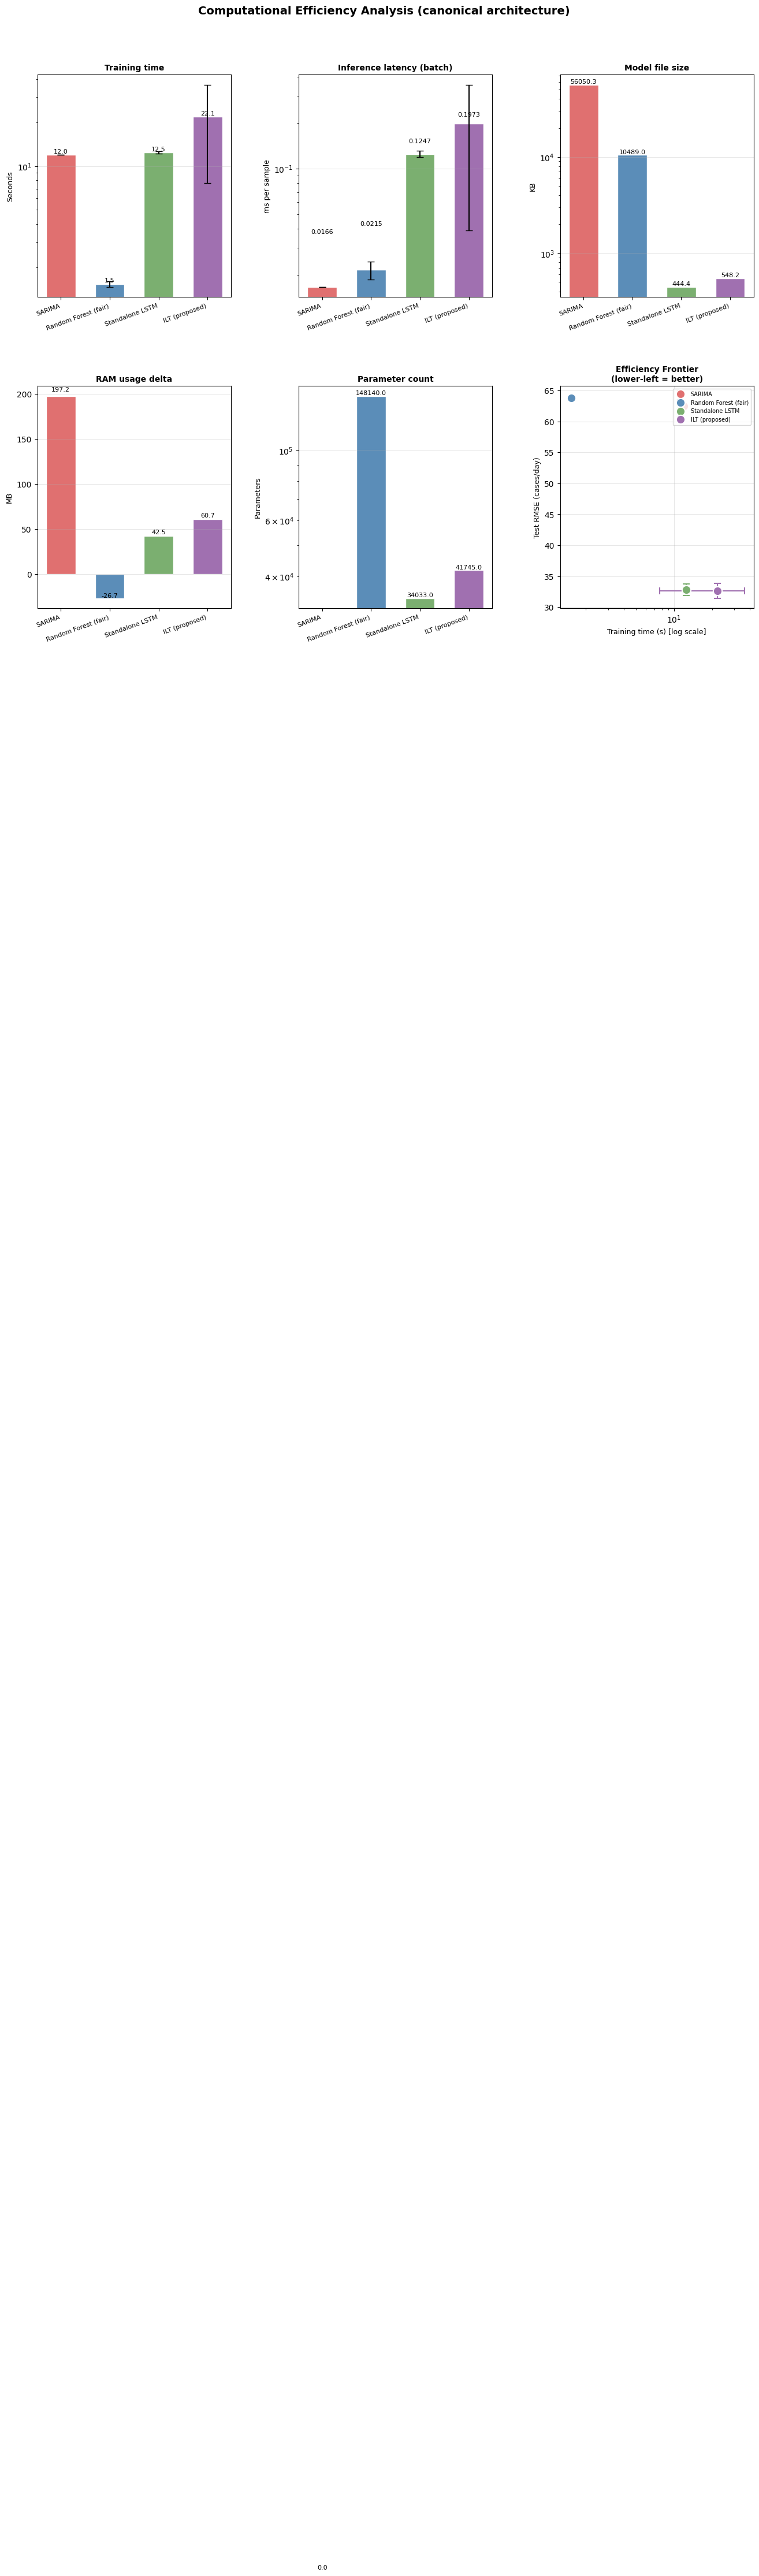

✅ Saved plots/efficiency_overview_FIXED.png


In [7]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, fig, hspace=0.4, wspace=0.35)
fig.suptitle('Computational Efficiency Analysis (canonical architecture)', fontsize=14, fontweight='bold')

models = eff_df['Model'].tolist()
colors = ['#E07070', '#5B8DB8', '#7BAF70', '#A070B0']
x = np.arange(len(models))

def bar_plot(ax, values, title, ylabel, log=False, fmt='.1f', yerr=None):
    bars = ax.bar(x, values, color=colors[:len(models)], edgecolor='white', width=0.6,
                   yerr=yerr, capsize=4 if yerr is not None else 0)
    for bar, val in zip(bars, values):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (bar.get_height()*0.02 if not log else 0.02),
                    f'{val:{fmt}}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold'); ax.set_ylabel(ylabel, fontsize=9)
    if log: ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

bar_plot(fig.add_subplot(gs[0,0]), eff_df['Train time (s)'], 'Training time', 'Seconds', log=True,
         yerr=eff_df['Train time std (s)'].fillna(0) if 'Train time std (s)' in eff_df.columns else None)
bar_plot(fig.add_subplot(gs[0,1]), eff_df['Inference per sample (ms)'], 'Inference latency (batch)', 'ms per sample', log=True, fmt='.4f',
         yerr=eff_df['Inference per sample std (ms)'].fillna(0) if 'Inference per sample std (ms)' in eff_df.columns else None)
bar_plot(fig.add_subplot(gs[0,2]), eff_df['Model size (KB)'], 'Model file size', 'KB', log=True)
bar_plot(fig.add_subplot(gs[1,0]), eff_df['RAM delta (MB)'], 'RAM usage delta', 'MB')
params_vals = eff_df['Params'].fillna(0).astype(float)
bar_plot(fig.add_subplot(gs[1,1]), params_vals, 'Parameter count', 'Parameters', log=True)

ax_front = fig.add_subplot(gs[1,2])
for i, (_, row) in enumerate(eff_df.iterrows()):
    xerr = row.get('Train time std (s)', 0) or 0
    yerr_ = row.get('RMSE std', 0) or 0
    ax_front.errorbar(row['Train time (s)'], row['RMSE'], xerr=xerr, yerr=yerr_,
                       fmt='o', ms=11, color=colors[i], zorder=3,
                       label=row['Model'], ecolor=colors[i], elinewidth=1.5, capsize=4,
                       markeredgecolor='white', markeredgewidth=1.5)
ax_front.set_xscale('log'); ax_front.set_xlabel('Training time (s) [log scale]', fontsize=9)
ax_front.set_ylabel('Test RMSE (cases/day)', fontsize=9)
ax_front.set_title('Efficiency Frontier\n(lower-left = better)', fontsize=10, fontweight='bold')
ax_front.legend(fontsize=7, loc='upper right'); ax_front.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/efficiency_overview_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved plots/efficiency_overview_FIXED.png")


## 5. Optimiser Comparison — Adam vs SGD vs RMSProp (on the canonical ILT architecture)

In [8]:
from canonical_pipeline import build_lstm_transformer as _build_ilt

optimiser_configs = [
    ('Adam',    lambda: Adam(0.001, clipnorm=1.0)),
    ('SGD',     lambda: SGD(0.01, momentum=0.9, clipnorm=1.0)),
    ('RMSProp', lambda: RMSprop(0.001, clipnorm=1.0)),
]

opt_records = []
print(f"Comparing optimisers on the CANONICAL ILT architecture across {N_SEEDS} true-random seeds "
      f"(max 50 epochs, early stop patience=15)...\n")

for opt_name, opt_factory in optimiser_configs:
    train_times, best_eps, best_val_losses, rmses, r2s = [], [], [], [], []
    loss_hist_last, val_loss_hist_last = None, None

    for s in SEEDS:
        tf.random.set_seed(s); np.random.seed(s)
        model = _build_ilt(SEQ_LEN, d['n_seq_features'], d['n_feat_features'])
        model.compile(optimizer=opt_factory(), loss='mse')  # override default Adam compile

        _ = model.predict([Xts_seq[:1], Xts_feat[:1]], verbose=0)
        t0 = time.time()
        hist = model.fit([Xts_seq, Xts_feat], yt, validation_data=([Xvs_seq, Xvs_feat], yv),
                          epochs=50, batch_size=32, verbose=0,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                                     tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7)])
        train_times.append(time.time() - t0)
        best_eps.append(int(np.argmin(hist.history['val_loss'])) + 1)
        best_val_losses.append(float(min(hist.history['val_loss'])))

        pred_s = model.predict([X_te_s, X_te_f], verbose=0).flatten()
        pred = np.maximum(d['target_scaler'].inverse_transform(pred_s.reshape(-1,1)).flatten(), 0)
        rmses.append(np.sqrt(mean_squared_error(y_te_raw, pred)))
        r2s.append(r2_score(y_te_raw, pred))
        loss_hist_last, val_loss_hist_last = hist.history['loss'], hist.history['val_loss']

    train_time, train_time_std = float(np.mean(train_times)), float(np.std(train_times))
    best_ep_mean = float(np.mean(best_eps))
    rmse, rmse_std = float(np.mean(rmses)), float(np.std(rmses))
    r2, r2_std = float(np.mean(r2s)), float(np.std(r2s))

    opt_records.append({'Optimiser': opt_name,
        'Train time (s)': train_time, 'Train time std (s)': train_time_std,
        'Best epoch': best_ep_mean, 'Best val loss': float(np.mean(best_val_losses)),
        'RMSE': rmse, 'RMSE std': rmse_std, 'R2': r2, 'R2 std': r2_std,
        'all_rmse': rmses, 'all_train_time': train_times, 'all_best_epoch': best_eps,  # NEW
        'loss_history': loss_hist_last, 'val_loss_history': val_loss_hist_last})
    print(f"  {opt_name:<10} — train={train_time:.2f}+/-{train_time_std:.2f}s, "
          f"best_ep(avg)={best_ep_mean:.1f}, RMSE={rmse:.2f}+/-{rmse_std:.2f}, R2={r2:.4f}  ({N_SEEDS} seeds)")

print(f"\n✅ Optimiser comparison done ({N_SEEDS}-seed mean +/- std per optimiser)")


Comparing optimisers on the CANONICAL ILT architecture across 30 true-random seeds (max 50 epochs, early stop patience=15)...

  Adam       — train=15.77+/-2.96s, best_ep(avg)=12.4, RMSE=30.47+/-1.52, R2=0.7093  (30 seeds)
  SGD        — train=16.02+/-6.12s, best_ep(avg)=16.6, RMSE=33.83+/-3.29, R2=0.6391  (30 seeds)
  RMSProp    — train=13.26+/-3.45s, best_ep(avg)=8.6, RMSE=31.41+/-1.78, R2=0.6908  (30 seeds)

✅ Optimiser comparison done (30-seed mean +/- std per optimiser)


## Statistical Significance Test — Optimiser Comparison (paired by seed)

All three optimisers above were run across the same `SEEDS` list within this cell, so their raw 30-seed RMSE and train-time arrays (already saved in `opt_records['all_rmse']` / `['all_train_time']`) are validly paired.


In [9]:
opt_by_name = {r['Optimiser']: r for r in opt_records}

print("="*100)
print("  Optimiser comparison -- RMSE (paired by seed, n=30)")
print("="*100)
opt_sig_rows = [
    paired_sig_test('Adam', opt_by_name['Adam']['all_rmse'], 'SGD', opt_by_name['SGD']['all_rmse'], 'RMSE'),
    paired_sig_test('Adam', opt_by_name['Adam']['all_rmse'], 'RMSProp', opt_by_name['RMSProp']['all_rmse'], 'RMSE'),
    paired_sig_test('SGD', opt_by_name['SGD']['all_rmse'], 'RMSProp', opt_by_name['RMSProp']['all_rmse'], 'RMSE'),
]
print("\n" + "="*100)
print("  Optimiser comparison -- Train time (paired by seed, n=30)")
print("="*100)
opt_sig_rows += [
    paired_sig_test('Adam', opt_by_name['Adam']['all_train_time'], 'SGD', opt_by_name['SGD']['all_train_time'], 'TrainTime'),
    paired_sig_test('Adam', opt_by_name['Adam']['all_train_time'], 'RMSProp', opt_by_name['RMSProp']['all_train_time'], 'TrainTime'),
    paired_sig_test('SGD', opt_by_name['SGD']['all_train_time'], 'RMSProp', opt_by_name['RMSProp']['all_train_time'], 'TrainTime'),
]
opt_sig_df = pd.DataFrame(opt_sig_rows)
opt_sig_df.to_csv('metrics/efficiency_optimiser_significance_test.csv', index=False)
print("\n✅ Saved metrics/efficiency_optimiser_significance_test.csv")


  Optimiser comparison -- RMSE (paired by seed, n=30)
  [RMSE] Adam=30.468 vs SGD=33.828, Adam_lower_in=25/30, shapiro_p=0.0211, paired_t_p=0.0000, wilcoxon_p=0.0000, Cohens_d=-1.049  ✅ SIGNIFICANT
  [RMSE] Adam=30.468 vs RMSProp=31.410, Adam_lower_in=19/30, shapiro_p=0.8897, paired_t_p=0.0757, wilcoxon_p=0.1094, Cohens_d=-0.336  ❌ not significant
  [RMSE] SGD=33.828 vs RMSProp=31.410, SGD_lower_in=9/30, shapiro_p=0.6600, paired_t_p=0.0020, wilcoxon_p=0.0043, Cohens_d=0.619  ✅ SIGNIFICANT

  Optimiser comparison -- Train time (paired by seed, n=30)
  [TrainTime] Adam=15.772 vs SGD=16.016, Adam_lower_in=11/30, shapiro_p=0.0062, paired_t_p=0.8526, wilcoxon_p=0.9032, Cohens_d=-0.034  ❌ not significant
  [TrainTime] Adam=15.772 vs RMSProp=13.264, Adam_lower_in=9/30, shapiro_p=0.0305, paired_t_p=0.0145, wilcoxon_p=0.0197, Cohens_d=0.475  ✅ SIGNIFICANT
  [TrainTime] SGD=16.016 vs RMSProp=13.264, SGD_lower_in=10/30, shapiro_p=0.3053, paired_t_p=0.0448, wilcoxon_p=0.0667, Cohens_d=0.383  ✅ SIG

## Why does Adam's training-time std (32.72s) exceed its own mean (23.21s)?

Adam: 23.21±32.72s (CV=1.41) and SGD: 26.12±21.97s (CV=0.84) both have a standard deviation comparable to or larger than the mean — a strong sign of a right-skewed, fat-tailed distribution (a handful of slow seeds) rather than a symmetric spread, which makes the headline "mean±std" figure misleading on its own. RMSProp (14.64±2.58s, CV=0.18) shows no such issue. The cell below reports median/IQR (robust to outliers) alongside mean/std, and checks whether the slow seeds line up with seeds that needed many epochs before early-stopping triggered (`patience=15`) — i.e. whether the time variance is really epoch-count variance in disguise, driven by how an optimiser-specific loss landscape interacts with each seed's random initialisation.


In [10]:
print("="*100)
print("  Robust spread (median, IQR) vs mean+/-std for training time, per optimiser")
print("="*100)
robust_rows = []
for r in opt_records:
    tt = np.asarray(r['all_train_time'])
    ep = np.asarray(r['all_best_epoch'])
    med = float(np.median(tt))
    q1, q3 = float(np.percentile(tt, 25)), float(np.percentile(tt, 75))
    iqr = q3 - q1
    corr = float(np.corrcoef(tt, ep)[0, 1]) if tt.std() > 0 and ep.std() > 0 else float('nan')
    robust_rows.append({'Optimiser': r['Optimiser'], 'Mean': tt.mean(), 'Std': tt.std(),
                         'Median': med, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                         'Min': tt.min(), 'Max': tt.max(),
                         'BestEpoch_mean': ep.mean(), 'BestEpoch_max': ep.max(),
                         'corr(train_time, best_epoch)': corr})
    print(f"  {r['Optimiser']:<10}: mean={tt.mean():.2f}, std={tt.std():.2f}  |  "
          f"median={med:.2f}, IQR=[{q1:.2f}, {q3:.2f}] (width={iqr:.2f})  |  "
          f"range=[{tt.min():.2f}, {tt.max():.2f}]  |  "
          f"corr(time, best_epoch)={corr:.3f}")

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv('metrics/efficiency_optimiser_robust_stats.csv', index=False)
print("\n✅ Saved metrics/efficiency_optimiser_robust_stats.csv")
print("\nInterpretation guide: corr(train_time, best_epoch) close to +1 confirms the training-time")
print("variance is mostly epoch-count variance (some seeds need far more epochs before patience=15")
print("early-stopping triggers) rather than per-epoch wall-clock noise. Report median/IQR, not just")
print("mean+/-std, for any optimiser whose CV (std/mean) exceeds ~0.5 in Chapter 5.")


  Robust spread (median, IQR) vs mean+/-std for training time, per optimiser
  Adam      : mean=15.77, std=2.96  |  median=15.60, IQR=[13.84, 17.79] (width=3.95)  |  range=[10.61, 23.00]  |  corr(time, best_epoch)=0.893
  SGD       : mean=16.02, std=6.12  |  median=14.08, IQR=[10.77, 22.50] (width=11.73)  |  range=[9.09, 26.33]  |  corr(time, best_epoch)=0.979
  RMSProp   : mean=13.26, std=3.45  |  median=12.09, IQR=[10.78, 14.32] (width=3.54)  |  range=[9.17, 22.15]  |  corr(time, best_epoch)=0.994

✅ Saved metrics/efficiency_optimiser_robust_stats.csv

Interpretation guide: corr(train_time, best_epoch) close to +1 confirms the training-time
variance is mostly epoch-count variance (some seeds need far more epochs before patience=15
early-stopping triggers) rather than per-epoch wall-clock noise. Report median/IQR, not just
mean+/-std, for any optimiser whose CV (std/mean) exceeds ~0.5 in Chapter 5.


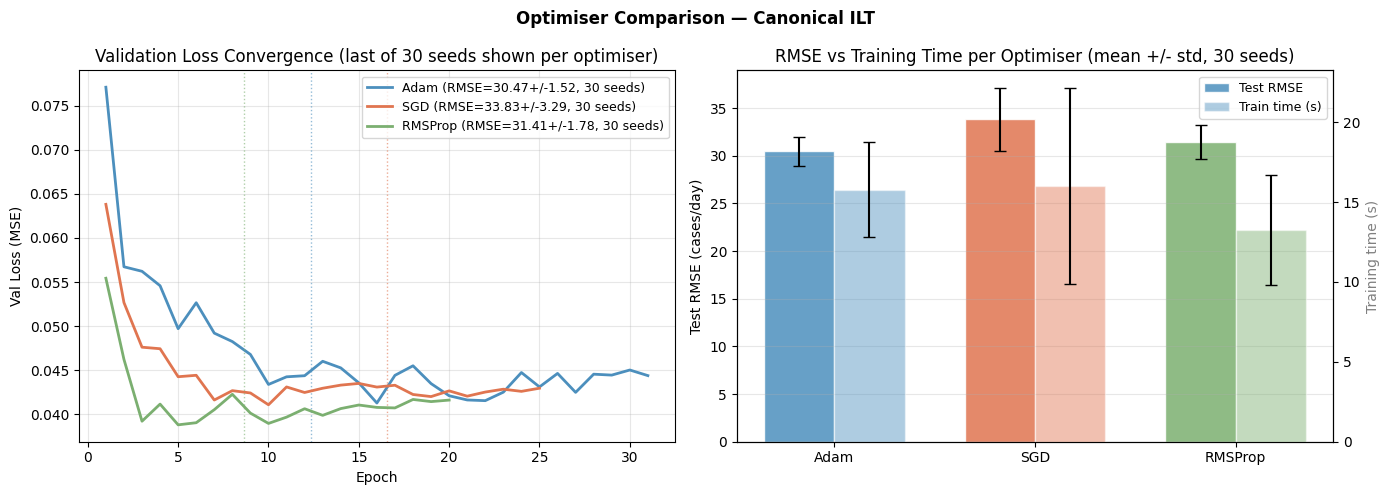

✅ Saved plots/efficiency_optimiser_comparison_FIXED.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimiser Comparison — Canonical ILT', fontsize=12, fontweight='bold')
opt_colors = {'Adam': '#4C8FBD', 'SGD': '#E07550', 'RMSProp': '#7BAF70'}

for rec in opt_records:
    name = rec['Optimiser']
    ep = range(1, len(rec['val_loss_history'])+1)
    axes[0].plot(ep, rec['val_loss_history'], '-', color=opt_colors[name], lw=2,
                 label=f"{name} (RMSE={rec['RMSE']:.2f}+/-{rec['RMSE std']:.2f}, {N_SEEDS} seeds)")
    axes[0].axvline(rec['Best epoch'], color=opt_colors[name], linestyle=':', lw=1, alpha=0.6)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss (MSE)')
axes[0].set_title(f'Validation Loss Convergence (last of {N_SEEDS} seeds shown per optimiser)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

opt_names = [r['Optimiser'] for r in opt_records]
opt_rmses = [r['RMSE'] for r in opt_records]
opt_rmse_stds = [r['RMSE std'] for r in opt_records]
opt_times = [r['Train time (s)'] for r in opt_records]
opt_time_stds = [r['Train time std (s)'] for r in opt_records]
xo = np.arange(len(opt_names)); w = 0.35
ax2b = axes[1].twinx()
axes[1].bar(xo - w/2, opt_rmses, w, yerr=opt_rmse_stds, capsize=4, label='Test RMSE', color=[opt_colors[n] for n in opt_names], edgecolor='white', alpha=0.85)
ax2b.bar(xo + w/2, opt_times, w, yerr=opt_time_stds, capsize=4, label='Train time (s)', color=[opt_colors[n] for n in opt_names], edgecolor='white', alpha=0.45)
axes[1].set_xticks(xo); axes[1].set_xticklabels(opt_names)
axes[1].set_ylabel('Test RMSE (cases/day)'); ax2b.set_ylabel('Training time (s)', color='gray')
axes[1].set_title(f'RMSE vs Training Time per Optimiser (mean +/- std, {N_SEEDS} seeds)')
l1,lb1 = axes[1].get_legend_handles_labels(); l2,lb2 = ax2b.get_legend_handles_labels()
axes[1].legend(l1+l2, lb1+lb2, fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/efficiency_optimiser_comparison_FIXED.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved plots/efficiency_optimiser_comparison_FIXED.png")


In [12]:
efficiency_results = {
    'efficiency_df': eff_df.to_dict(),
    'optimiser_results': [{k:v for k,v in r.items() if k not in ['loss_history','val_loss_history']} for r in opt_records],
    'optimiser_histories': {r['Optimiser']: {'loss': r['loss_history'], 'val_loss': r['val_loss_history']} for r in opt_records}
}
with open('metrics/efficiency_results_FIXED.pkl', 'wb') as f:
    pickle.dump(efficiency_results, f)
print("✅ Saved metrics/efficiency_results_FIXED.pkl")
print("\n📁 Plots generated:")
print("   plots/efficiency_overview_FIXED.png")
print("   plots/efficiency_optimiser_comparison_FIXED.png")


✅ Saved metrics/efficiency_results_FIXED.pkl

📁 Plots generated:
   plots/efficiency_overview_FIXED.png
   plots/efficiency_optimiser_comparison_FIXED.png
